# Experiment 2: Email Spam/Ham Classification using Naïve Bayes and KNN
**Sri Sivasubramaniya Nadar College of Engineering, Chennai**
**Machine Learning Algorithms Laboratory — ICS1512**

**Dataset:** Spambase (Kaggle) — https://www.kaggle.com/datasets/somesh24/spambase




## 1. Imports and Setup

In [4]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold,
                                      cross_val_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
np.random.seed(42)

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)
sns.set_style("whitegrid")

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, name), dpi=150, bbox_inches="tight")
    plt.show()


## 2. Load Dataset


In [5]:
DATA_FILE = "spambase_csv.csv"
if not os.path.exists(DATA_FILE):
    alt = "spambase.data"
    if os.path.exists(alt):
        n_features = 57
        cols = [f"f{i}" for i in range(n_features)] + ["spam"]
        df = pd.read_csv(alt, header=None, names=cols)
    else:
        raise FileNotFoundError(
            f"Could not find '{DATA_FILE}'. Download the Spambase dataset from "
            "https://www.kaggle.com/datasets/somesh24/spambase and place it here."
        )
else:
    df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [6]:
target_col = "spam" if "spam" in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
print("Target column:", target_col)
print(y.value_counts())


Target column: class
class
0    2788
1    1813
Name: count, dtype: int64


## 3. Handle Missing Values

In [7]:
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean(numeric_only=True))
print("Missing values after handling:", X.isnull().sum().sum())


Missing values after handling: 0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Class Distribution

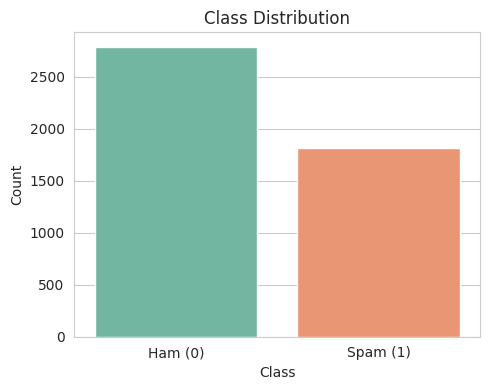

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y, hue=y, palette="Set2", legend=False)
plt.xticks([0, 1], ["Ham (0)", "Spam (1)"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
savefig("01_class_distribution.png")


### 4.2 Correlation Heatmap (Top 15 Features vs Target)

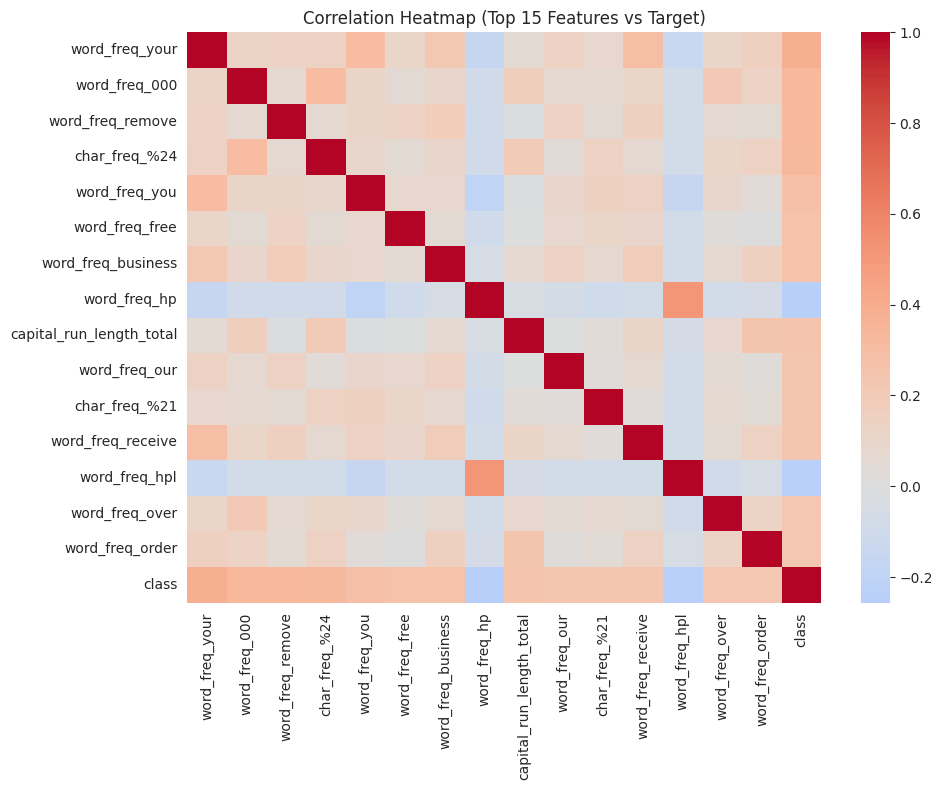

In [9]:
corr = X.copy()
corr[target_col] = y
full_corr = corr.corr()
top_feats = full_corr[target_col].abs().sort_values(ascending=False)[1:16].index

plt.figure(figsize=(10, 8))
sns.heatmap(corr[list(top_feats) + [target_col]].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Top 15 Features vs Target)")
savefig("02_correlation_heatmap.png")


### 4.3 Histograms of Important Features

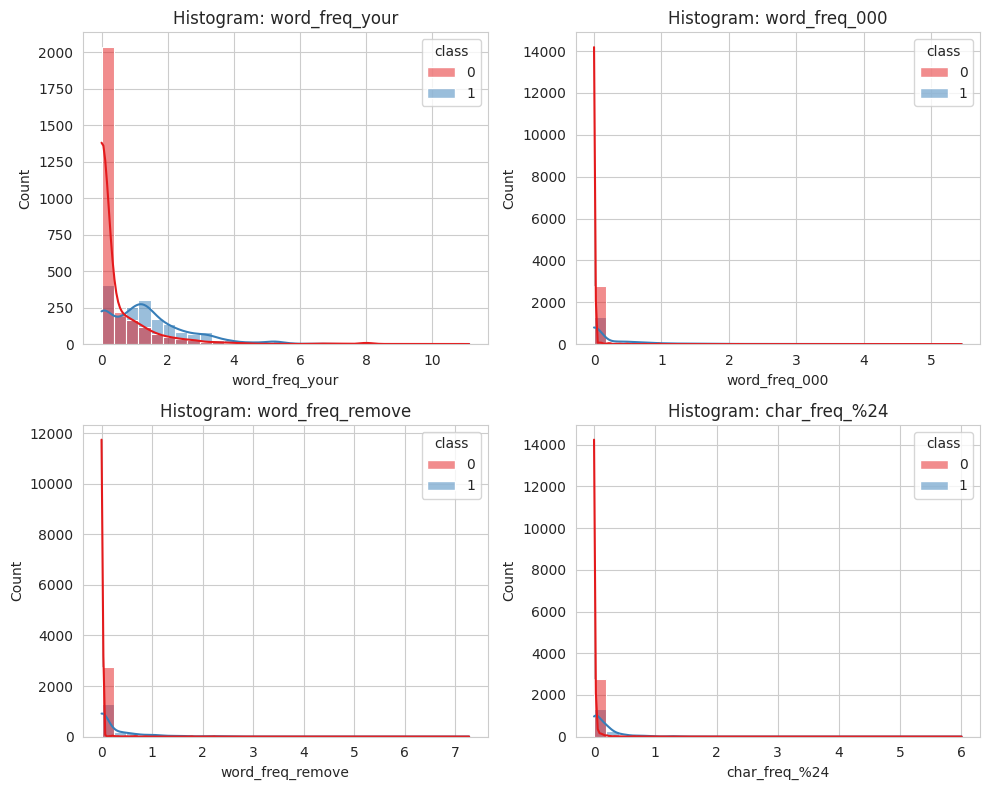

In [10]:
important_feats = top_feats[:4]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), important_feats):
    sns.histplot(data=corr, x=feat, hue=target_col, bins=30, kde=True, ax=ax, palette="Set1")
    ax.set_title(f"Histogram: {feat}")
savefig("03_histograms_important_features.png")


### 4.4 Boxplots

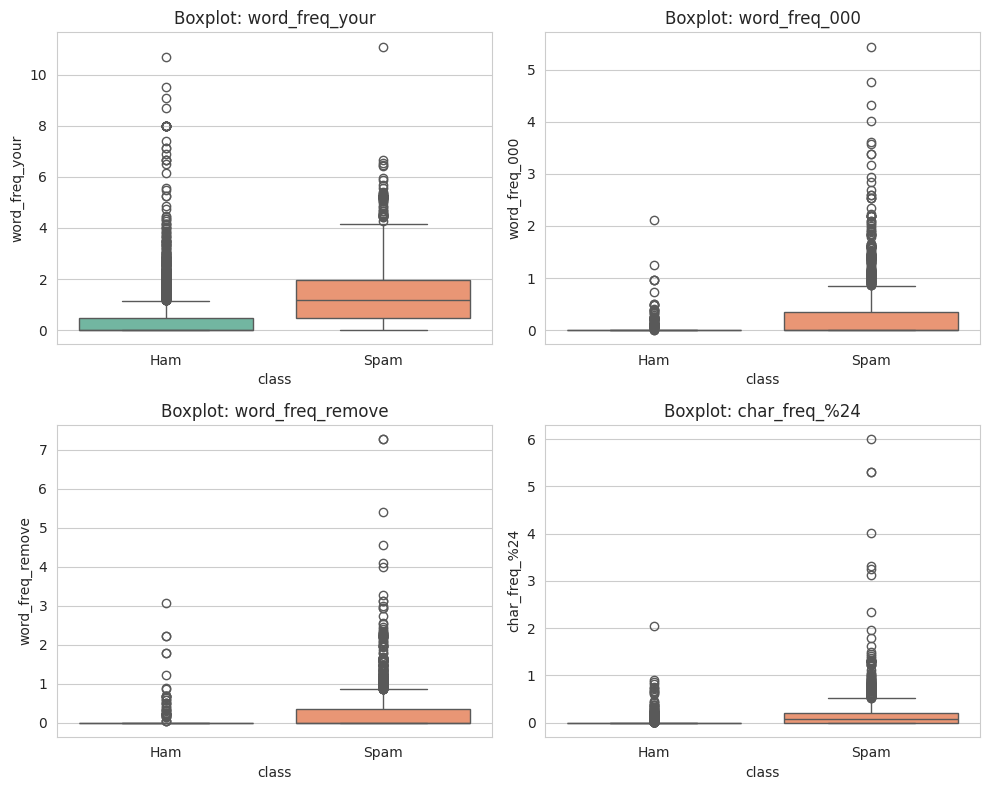

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), important_feats):
    sns.boxplot(data=corr, x=target_col, y=feat, hue=target_col, ax=ax, palette="Set2", legend=False)
    ax.set_title(f"Boxplot: {feat}")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Ham", "Spam"])
savefig("04_boxplots.png")


## 5. Feature Scaling and Train-Test Split

- **StandardScaler** for Gaussian NB and KNN (can be negative).
- **MinMaxScaler** for Multinomial/Bernoulli NB (require non-negative inputs).

In [12]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train_raw)
X_test_mm = mm_scaler.transform(X_test_raw)

print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")


Train shape: (3450, 57), Test shape: (1151, 57)


## 6. Model Evaluation Helper

In [13]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t0

    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Train_Time": train_time,
        "Pred_Time": pred_time,
    }
    return metrics, y_pred, y_proba


## 7. Train Naïve Bayes Variants (Gaussian, Multinomial, Bernoulli)

In [14]:
nb_results = []
nb_preds = {}
nb_probas = {}

m, p, pr = evaluate_model(GaussianNB(), X_train_scaled, X_test_scaled, y_train, y_test, "Gaussian NB")
nb_results.append(m); nb_preds["Gaussian NB"] = p; nb_probas["Gaussian NB"] = pr

m, p, pr = evaluate_model(MultinomialNB(), X_train_mm, X_test_mm, y_train, y_test, "Multinomial NB")
nb_results.append(m); nb_preds["Multinomial NB"] = p; nb_probas["Multinomial NB"] = pr

m, p, pr = evaluate_model(BernoulliNB(), X_train_mm, X_test_mm, y_train, y_test, "Bernoulli NB")
nb_results.append(m); nb_preds["Bernoulli NB"] = p; nb_probas["Bernoulli NB"] = pr

nb_df = pd.DataFrame(nb_results)
nb_df.to_csv(os.path.join(OUT, "table_naive_bayes_comparison.csv"), index=False)
nb_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gaussian NB,0.825369,0.707718,0.949339,0.810913,0.936771
1,Multinomial NB,0.900087,0.947230,0.790749,0.861945,0.961433
2,Bernoulli NB,0.883579,0.873832,0.823789,0.848073,0.947841


In [15]:
best_nb_name = nb_df.loc[nb_df["Accuracy"].idxmax(), "Model"]
print("Best Naive Bayes variant:", best_nb_name)


Best Naive Bayes variant: Multinomial NB


## 8. KNN for Varying k

In [16]:
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    m, p, pr = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test, f"k={k}")
    knn_k_results.append({"k": k, "Accuracy": m["Accuracy"], "Precision": m["Precision"],
                           "Recall": m["Recall"], "F1": m["F1"]})

knn_k_df = pd.DataFrame(knn_k_results)
knn_k_df.to_csv(os.path.join(OUT, "table_knn_k_comparison.csv"), index=False)
knn_k_df


,k,Accuracy,Precision,Recall,F1
0,1,0.897480,0.873333,0.865639,0.869469
1,3,0.901825,0.881432,0.867841,0.874584
2,5,0.899218,0.878924,0.863436,0.871111
3,7,0.905300,0.892938,0.863436,0.877940
4,9,0.906169,0.893182,0.865639,0.879195
5,11,0.902693,0.890411,0.859031,0.874439


In [17]:
best_k = knn_k_df.loc[knn_k_df["Accuracy"].idxmax(), "k"]
print("Best k:", best_k)


Best k: 9


### 8.1 Accuracy vs k Plot

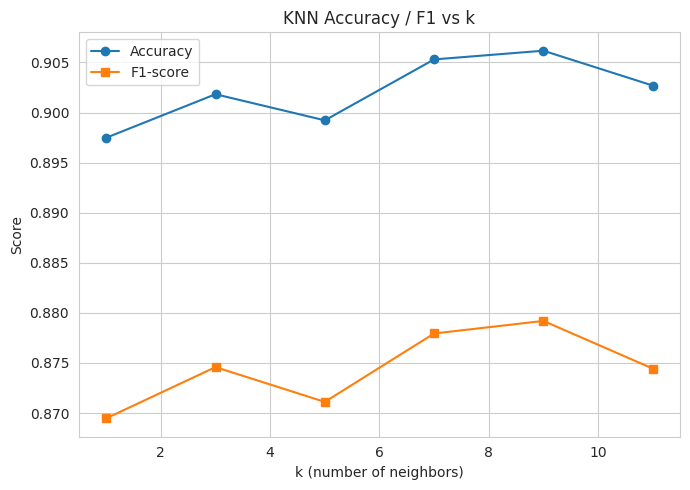

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(knn_k_df["k"], knn_k_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(knn_k_df["k"], knn_k_df["F1"], marker="s", label="F1-score")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN Accuracy / F1 vs k")
plt.legend()
savefig("08_accuracy_vs_k.png")


## 9. GridSearchCV vs RandomizedSearchCV

In [19]:

param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree"],
    "metric": ["euclidean", "manhattan"],
}

t0 = time.time()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5,
                            scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
grid_time = time.time() - t0

t0 = time.time()
rand_search = RandomizedSearchCV(KNeighborsClassifier(), param_grid, cv=5,
                                  scoring="accuracy", n_iter=15, n_jobs=-1,
                                  random_state=42)
rand_search.fit(X_train_scaled, y_train)
rand_time = time.time() - t0

search_comparison = pd.DataFrame({
    "Parameter": ["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Execution Time (s)"],
    "GridSearchCV": [
        grid_search.best_params_["n_neighbors"],
        grid_search.best_params_["metric"],
        grid_search.best_params_["weights"],
        grid_search.best_params_["algorithm"],
        round(grid_search.best_score_, 4),
        round(grid_time, 3),
    ],
    "RandomizedSearchCV": [
        rand_search.best_params_["n_neighbors"],
        rand_search.best_params_["metric"],
        rand_search.best_params_["weights"],
        rand_search.best_params_["algorithm"],
        round(rand_search.best_score_, 4),
        round(rand_time, 3),
    ],
})
search_comparison.to_csv(os.path.join(OUT, "table_grid_vs_random_search.csv"), index=False)
search_comparison


,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,9,15
1,Metric,manhattan,manhattan
2,Weights,distance,distance
3,Algorithm,auto,auto
4,CV Accuracy,0.9226,0.92
5,Execution Time (s),6.691,0.773


### 9.1 GridSearchCV Heatmap

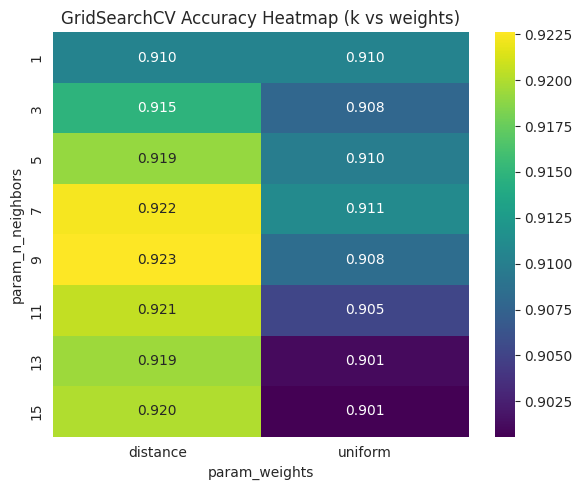

In [20]:
grid_res = pd.DataFrame(grid_search.cv_results_)
pivot_data = grid_res[grid_res["param_metric"] == grid_search.best_params_["metric"]]
pivot = pivot_data.pivot_table(index="param_n_neighbors", columns="param_weights",
                                values="mean_test_score", aggfunc="mean")
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("GridSearchCV Accuracy Heatmap (k vs weights)")
savefig("13_gridsearch_heatmap.png")


### 9.2 RandomizedSearchCV Score Distribution

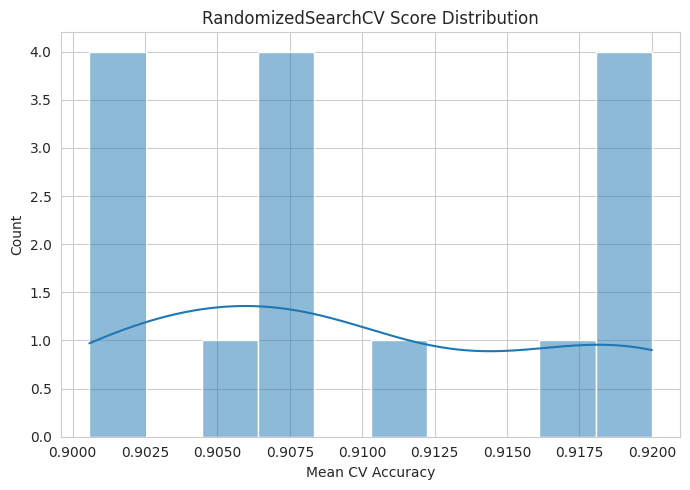

In [21]:
plt.figure(figsize=(7, 5))
sns.histplot(pd.DataFrame(rand_search.cv_results_)["mean_test_score"], bins=10, kde=True)
plt.xlabel("Mean CV Accuracy")
plt.title("RandomizedSearchCV Score Distribution")
savefig("14_randomsearch_score_distribution.png")

best_knn = grid_search.best_estimator_


## 10. KDTree vs BallTree

In [22]:
tree_results = []
for algo in ["kd_tree", "ball_tree"]:
    knn_algo = KNeighborsClassifier(n_neighbors=int(best_k), algorithm=algo)
    m, p, pr = evaluate_model(knn_algo, X_train_scaled, X_test_scaled, y_train, y_test, algo)
    tree_results.append(m)

tree_df = pd.DataFrame(tree_results)[["Model", "Accuracy", "Train_Time", "Pred_Time"]]
tree_df.columns = ["Algorithm", "Accuracy", "Training Time", "Prediction Time"]
tree_df.to_csv(os.path.join(OUT, "table_kdtree_vs_balltree.csv"), index=False)
tree_df


,Algorithm,Accuracy,Training Time,Prediction Time
0,kd_tree,0.906169,0.006071,0.119588
1,ball_tree,0.906169,0.004085,0.093528


## 11. 5-Fold Cross Validation

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_model_map = {"Gaussian NB": (GaussianNB(), X_train_scaled),
                 "Multinomial NB": (MultinomialNB(), X_train_mm),
                 "Bernoulli NB": (BernoulliNB(), X_train_mm)}
best_nb_model, best_nb_X = nb_model_map[best_nb_name]

cv_nb_scores = cross_val_score(best_nb_model, best_nb_X, y_train, cv=skf, scoring="accuracy")
cv_knn_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=skf, scoring="accuracy")

cv_df = pd.DataFrame({
    "Fold": list(range(1, 6)) + ["Average"],
    f"Naive Bayes ({best_nb_name})": list(cv_nb_scores) + [cv_nb_scores.mean()],
    "Best KNN": list(cv_knn_scores) + [cv_knn_scores.mean()],
})
cv_df.to_csv(os.path.join(OUT, "table_cross_validation.csv"), index=False)
cv_df


,Fold,Naive Bayes (Multinomial NB),Best KNN
0,1,0.885507,0.913043
1,2,0.897101,0.928986
2,3,0.894203,0.937681
3,4,0.882609,0.923188
4,5,0.881159,0.913043
5,Average,0.888116,0.923188


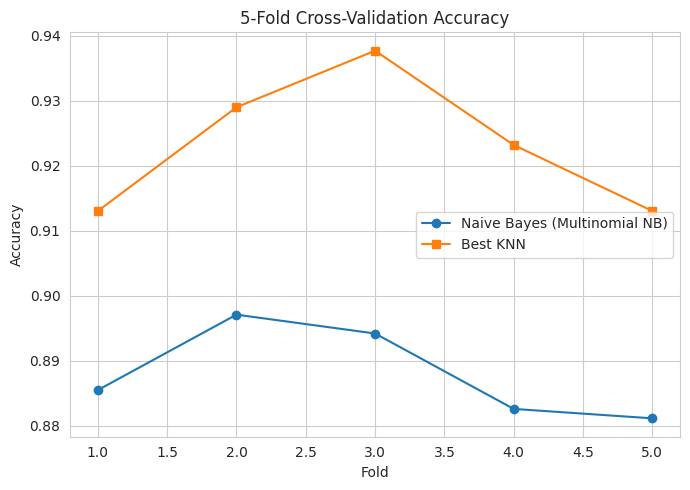

In [24]:
plt.figure(figsize=(7, 5))
x = np.arange(1, 6)
plt.plot(x, cv_nb_scores, marker="o", label=f"Naive Bayes ({best_nb_name})")
plt.plot(x, cv_knn_scores, marker="s", label="Best KNN")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
savefig("09_cv_accuracy.png")


## 12. Theoretical vs Experimental Time Complexity

In [25]:
theoretical = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "KNN (Brute)", "KDTree", "BallTree"],
    "Training": ["O(nd)", "O(1)", "O(n log n)", "O(n log n)"],
    "Prediction": ["O(d)", "O(nd)", "O(log n) avg", "O(log n) avg"],
})
theoretical.to_csv(os.path.join(OUT, "table_theoretical_complexity.csv"), index=False)
theoretical


,Algorithm,Training,Prediction
0,Naive Bayes,O(nd),O(d)
1,KNN (Brute),O(1),O(nd)
2,KDTree,O(n log n),O(log n) avg
3,BallTree,O(n log n),O(log n) avg


In [26]:
exp_time_df = pd.DataFrame(nb_results)[["Model", "Train_Time", "Pred_Time"]]
best_knn_row = {"Model": "Best KNN", "Train_Time": tree_df.loc[tree_df["Accuracy"].idxmax(), "Training Time"],
                "Pred_Time": tree_df.loc[tree_df["Accuracy"].idxmax(), "Prediction Time"]}
exp_time_df = pd.concat([exp_time_df, pd.DataFrame([best_knn_row])], ignore_index=True)
exp_time_df.columns = ["Algorithm", "Training(s)", "Prediction(s)"]
exp_time_df.to_csv(os.path.join(OUT, "table_experimental_time.csv"), index=False)
exp_time_df


,Algorithm,Training(s),Prediction(s)
0,Gaussian NB,0.003414,0.003030
1,Multinomial NB,0.001127,0.000161
2,Bernoulli NB,0.002414,0.000757
3,Best KNN,0.006071,0.119588


### 12.1 Training / Prediction Time Comparison Plots

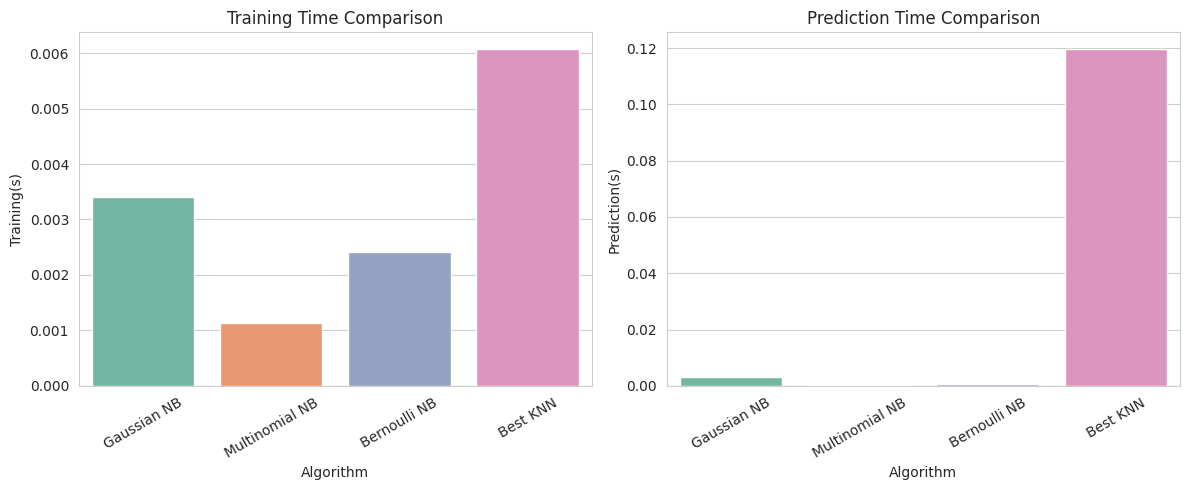

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=exp_time_df, x="Algorithm", y="Training(s)", hue="Algorithm", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Training Time Comparison")
axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=exp_time_df, x="Algorithm", y="Prediction(s)", hue="Algorithm", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Prediction Time Comparison")
axes[1].tick_params(axis='x', rotation=30)
savefig("10_11_time_comparison.png")


## 13. Confusion Matrices, ROC Curves, Precision-Recall Curves

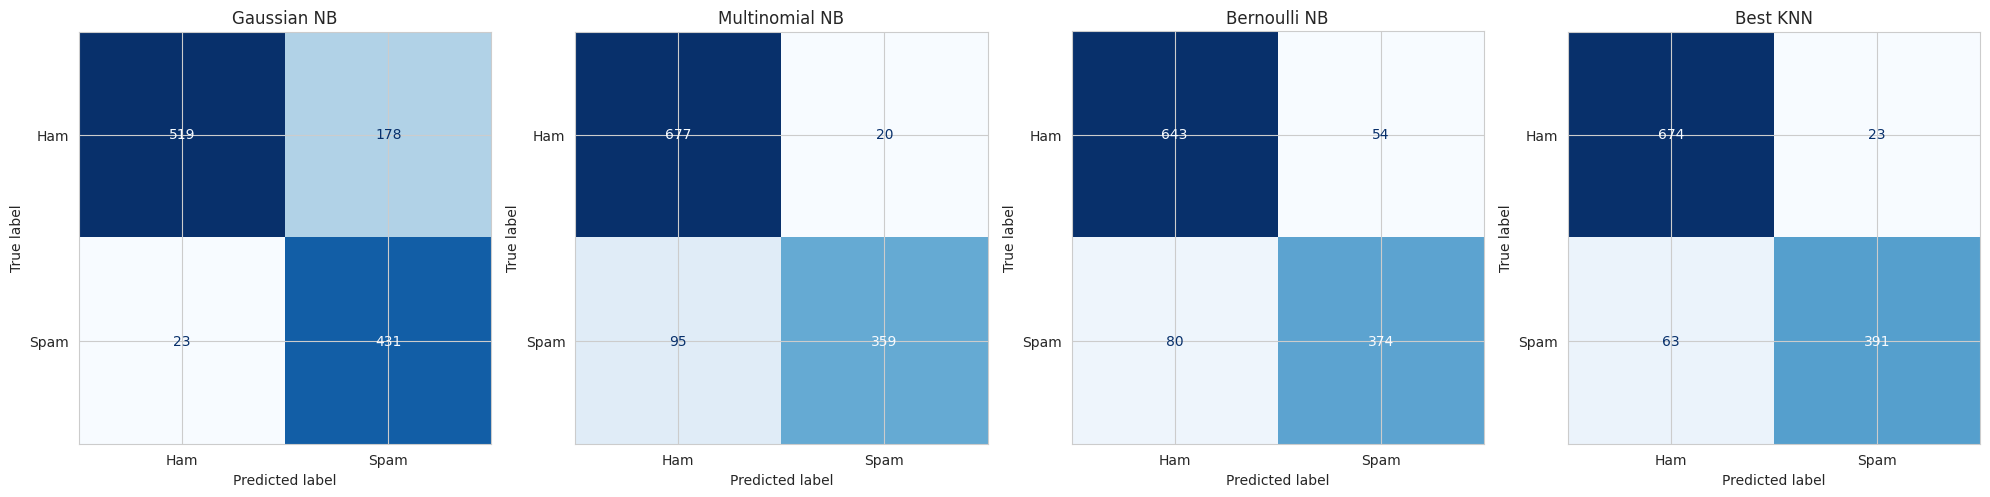

In [28]:
all_preds = dict(nb_preds)
all_probas = dict(nb_probas)
best_knn_pred = best_knn.predict(X_test_scaled)
best_knn_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
all_preds["Best KNN"] = best_knn_pred
all_probas["Best KNN"] = best_knn_proba

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
savefig("05_confusion_matrices.png")


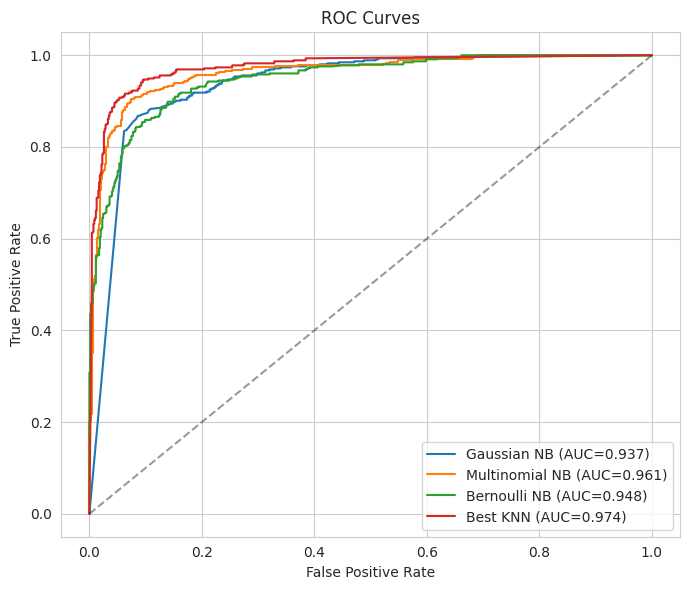

In [29]:
plt.figure(figsize=(7, 6))
for name, proba in all_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
savefig("06_roc_curves.png")


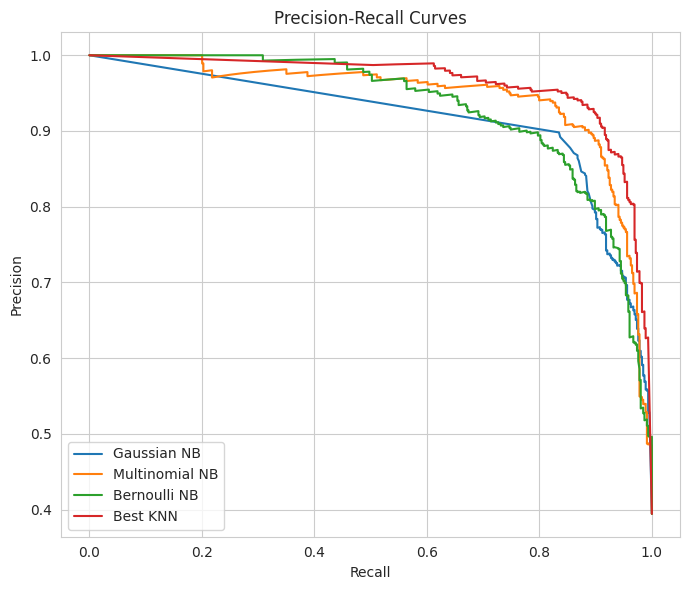

In [30]:
plt.figure(figsize=(7, 6))
for name, proba in all_probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
savefig("07_precision_recall_curves.png")


## 14. Classifier Comparison Bar Chart

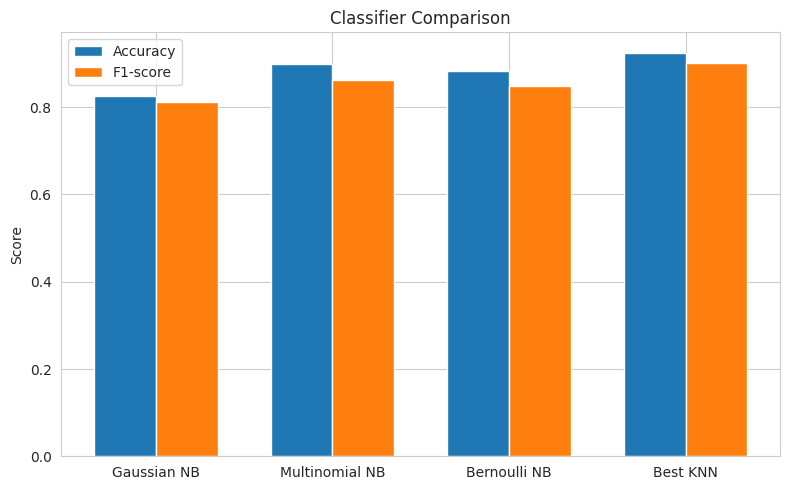

In [31]:
final_compare = []
for name in ["Gaussian NB", "Multinomial NB", "Bernoulli NB"]:
    row = nb_df[nb_df["Model"] == name].iloc[0]
    final_compare.append({"Model": name, "Accuracy": row["Accuracy"], "F1": row["F1"]})
final_compare.append({
    "Model": "Best KNN",
    "Accuracy": accuracy_score(y_test, best_knn_pred),
    "F1": f1_score(y_test, best_knn_pred),
})
final_df = pd.DataFrame(final_compare)

plt.figure(figsize=(8, 5))
x = np.arange(len(final_df))
width = 0.35
plt.bar(x - width/2, final_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, final_df["F1"], width, label="F1-score")
plt.xticks(x, final_df["Model"])
plt.ylabel("Score")
plt.title("Classifier Comparison")
plt.legend()
savefig("12_classifier_comparison.png")


## 15. Additional Tasks

### 15.1 Different Train-Test Splits

In [32]:
split_results = []
for test_size in [0.2, 0.25, 0.3, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    knn = KNeighborsClassifier(n_neighbors=int(best_k))
    knn.fit(Xtr_s, ytr)
    acc = accuracy_score(yte, knn.predict(Xte_s))
    split_results.append({"Test Size": test_size, "Accuracy": acc})
split_df = pd.DataFrame(split_results)
split_df.to_csv(os.path.join(OUT, "table_train_test_splits.csv"), index=False)
split_df


,Test Size,Accuracy
0,0.20,0.908795
1,0.25,0.906169
2,0.30,0.907314
3,0.40,0.902770


### 15.2 Euclidean vs Manhattan Distance

In [33]:
dist_results = []
for metric in ["euclidean", "manhattan"]:
    knn = KNeighborsClassifier(n_neighbors=int(best_k), metric=metric)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    dist_results.append({"Metric": metric, "Accuracy": acc})
dist_df = pd.DataFrame(dist_results)
dist_df.to_csv(os.path.join(OUT, "table_distance_metrics.csv"), index=False)
dist_df


,Metric,Accuracy
0,euclidean,0.906169
1,manhattan,0.913119


### 15.3 Weighted KNN (uniform vs distance)

In [34]:
weight_results = []
for w in ["uniform", "distance"]:
    knn = KNeighborsClassifier(n_neighbors=int(best_k), weights=w)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    weight_results.append({"Weights": w, "Accuracy": acc})
weight_df = pd.DataFrame(weight_results)
weight_df.to_csv(os.path.join(OUT, "table_weighted_knn.csv"), index=False)
weight_df


,Weights,Accuracy
0,uniform,0.906169
1,distance,0.913988


## 16. Summary

In [35]:
print("All tables and plots saved to:", os.path.abspath(OUT))
print(f"Best Naive Bayes variant: {best_nb_name}")
print(f"Best k for KNN: {best_k}")
print(f"Best search method params: {grid_search.best_params_}")


All tables and plots saved to: /home/jarvis/python/outputs
Best Naive Bayes variant: Multinomial NB
Best k for KNN: 9
Best search method params: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
